In [32]:
import pandas as pd
import numpy as np
df = pd.read_stata('Integration.dta')
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
#1.a.
# Descriptive analysis

df['2014'] = (df.ankomstaar == 2014.0)
df['2014'] = df['2014'].astype('int')
df['2015'] = (df.ankomstaar == 2015.0)
df['2015'] = df['2015'].astype('int')
df['2016'] = (df.ankomstaar == 2016.0)
df['2016'] = df['2016'].astype('int')

#Tabel
raekker = ['aarslon', 'alder', '2014', '2015', '2016']
tabel = df.groupby(['mand', 'aar'])[raekker].mean().T
tabel = tabel.round(2)
tabel


mand          0.0                 1.0          
aar        2017.0    2018.0    2017.0    2018.0
aarslon  31124.44  40045.05  61324.05  90906.50
alder       28.63     29.63     28.67     29.67
2014         0.34      0.34      0.33      0.33
2015         0.34      0.34      0.32      0.32
2016         0.32      0.32      0.35      0.35

In [34]:
#1.b.

df['YSM'] = df['aar'] - df['ankomstaar'] #years since migration
df17 = df[df['aar'] == 2017].copy() #tværsnit for 2017

df17['const'] = 1 #tilføjer en konstant
X = df17[['const', 'alder', 'YSM']].values #forklarende variable
y = np.log(df17['aarslon']).values

n = X.shape[0] #antal rækker = 2400
k = X.shape[1] - 1  # antal forklarende variable (kolonner) (ikke inkl. konstant)

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat = X @ beta_hat
residualer = y - y_hat
SSR = np.sum(residualer ** 2) #Sum of squared residuals

sigma2_hat = SSR/(n-k-1)

se_beta = np.sqrt(np.diag(sigma2_hat * np.linalg.inv(X.T @ X))) #standarderror


print(f"beta_0: estimat = {beta_hat[0]:.4f}, std. fejl = {se_beta[0]:.4f}")
print(f"beta_1: estimat = {beta_hat[1]:.4f}, std. fejl = {se_beta[1]:.4f}")
print(f"beta_2:   estimat = {beta_hat[2]:.4f}, std. fejl = {se_beta[2]:.4f}")



beta_0: estimat = 10.4231, std. fejl = 0.0474
beta_1: estimat = 0.0071, std. fejl = 0.0014
beta_2:   estimat = 0.0870, std. fejl = 0.0119


In [35]:
#1c
df17['YSM-alder'] = df['YSM'] - df['alder'] #tilføjer ny variabel (YSM - alder)

X = df17[['const', 'alder', 'YSM-alder']].values #model med nye variable
y = np.log(df17['aarslon']).values

n = X.shape[0] #antal rækker = 2400
k = X.shape[1] - 1  # antal forklarende variable (kolonner) (ikke inkl. konstant)

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat = X @ beta_hat
residualer = y - y_hat
SSR = np.sum(residualer ** 2) #Sum of squared residuals

sigma2_hat = SSR/(n-k-1)

se_beta = np.sqrt(np.diag(sigma2_hat * np.linalg.inv(X.T @ X))) #standarderror


print(f"beta_0: estimat = {beta_hat[0]:.4f}, std. fejl = {se_beta[0]:.4f}")
print(f"theta: estimat = {beta_hat[1]:.4f}, std. fejl = {se_beta[1]:.4f}")
print(f"beta_2:   estimat = {beta_hat[2]:.4f}, std. fejl = {se_beta[2]:.4f}")

tabel_1b = pd.DataFrame({
    'Koefficient': koefficienter,
    'Variabel': variable,
    'Estimat' : beta_hat,
    'Standardfejl' : se_beta
})
tabel_1b.round(4)

beta_0: estimat = 10.4231, std. fejl = 0.0474
theta: estimat = 0.0942, std. fejl = 0.0120
beta_2:   estimat = 0.0870, std. fejl = 0.0119


,Koefficient,Variabel,Estimat,Standardfejl
0,beta_0,-,10.4231,0.0474
1,beta_1,alder,0.0942,0.0120
2,beta_2,YSM,0.0870,0.0119


In [36]:
#2.a.

df['const'] = 1 #tilføjer konstant til df
X = df[['const', 'alder', 'YSM', 'ankomstaar']].values #forklarende variable
y = np.log(df['aarslon']).values

n = X.shape[0] #antal rækker = 4800
k = X.shape[1] - 1  # antal forklarende variable (kolonner) (ikke inkl. konstant)

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat = X @ beta_hat
residualer = y - y_hat
SSR = np.sum(residualer ** 2) #Sum of squared residuals

sigma2_hat = SSR/(n-k-1)

se_beta = np.sqrt(np.diag(sigma2_hat * np.linalg.inv(X.T @ X))) #standarderror


print(f"beta_0: estimat = {beta_hat[0]:.4f}, std. fejl = {se_beta[0]:.4f}")
print(f"beta_1: estimat = {beta_hat[1]:.4f}, std. fejl = {se_beta[1]:.4f}")
print(f"beta_2:   estimat = {beta_hat[2]:.4f}, std. fejl = {se_beta[2]:.4f}")
print(f"beta_3:   estimat = {beta_hat[3]:.4f}, std. fejl = {se_beta[3]:.4f}")



beta_0: estimat = -457.8689, std. fejl = 38.8181
beta_1: estimat = 0.0056, std. fejl = 0.0012
beta_2:   estimat = 0.2889, std. fejl = 0.0165
beta_3:   estimat = 0.2322, std. fejl = 0.0192


In [37]:
#3.a.

df['alder2'] = df['alder'] ** 2
df['YSM2'] = df['YSM'] ** 2

df['kohorte15'] = (df.ankomstaar == 2015.0).astype(int)
df['kohorte16'] = (df.ankomstaar == 2016.0).astype(int)

X = df[['const', 'alder', 'alder2', 'YSM', 'YSM2', 'kohorte15', 'kohorte16']]
y = np.log(df['aarslon'])

model3 = sm.OLS(y,X).fit()
results = model3.summary()
print(results)




                            OLS Regression Results                            
Dep. Variable:                aarslon   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     114.6
Date:                Thu, 08 Oct 2026   Prob (F-statistic):          1.48e-135
Time:                        22:20:57   Log-Likelihood:                -3961.5
No. Observations:                4800   AIC:                             7937.
Df Residuals:                    4793   BIC:                             7982.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0633      0.128     62.821      0.0

In [38]:
#3.b.(i)

df['kohorte_lin'] = df['kohorte15'] + 2 * df['kohorte16']
X_r = df[['const', 'alder', 'YSM', 'kohorte_lin']]

model_r = sm.OLS(y, X_r).fit()

SSR_r = model_r.ssr
SSR_ur = model3.ssr
q = 3 #antal restriktioner
n = len(y) #antal observationer
k_ur = 6 #forklarende variable i urestrikterede model

F_stat = ((SSR_r - SSR_ur) / q) / (SSR_ur / (n - k_ur - 1))
p = stats.f.sf(F_stat, q, n-k_ur-1)

print(f'{F_stat = :.4f}')
print(f'{p = :.2e}')


F_stat = 96.3058
p = 1.59e-60


In [39]:
#3.b.(ii)

y = np.log(df['aarslon'])
X = df[['const', 'alder', 'alder2', 'YSM', 'YSM2', 'kohorte15', 'kohorte16']]

mand = df['mand'] == 1 
kvinde = df['mand'] == 0

# Samlet (restrikteret) model = model (3)
model_r = sm.OLS(y, X).fit()

#Separate modeller
model_m = sm.OLS(y[mand],  X[mand]).fit()
model_k = sm.OLS(y[kvinde], X[kvinde]).fit()

#SSR'er
SSR_r  = model_r.ssr
SSR_ur = model_m.ssr + model_k.ssr

#Chow-test
k   = 6
n   = len(y)
q   = 7                    # 7 restriktioner -> alle 7 koefficienter skal være ens
df2 = n - 2*(k + 1)            # 4786 -> antal frihedsgrader i den urestrikterede model

F = ((SSR_r - SSR_ur) / q) / (SSR_ur / df2)
p = stats.f.sf(F, q, df2)

print(f'{F = :.4f}')
print(f'{p = :.2e}')


F = 321.4585
p = 0.00e+00


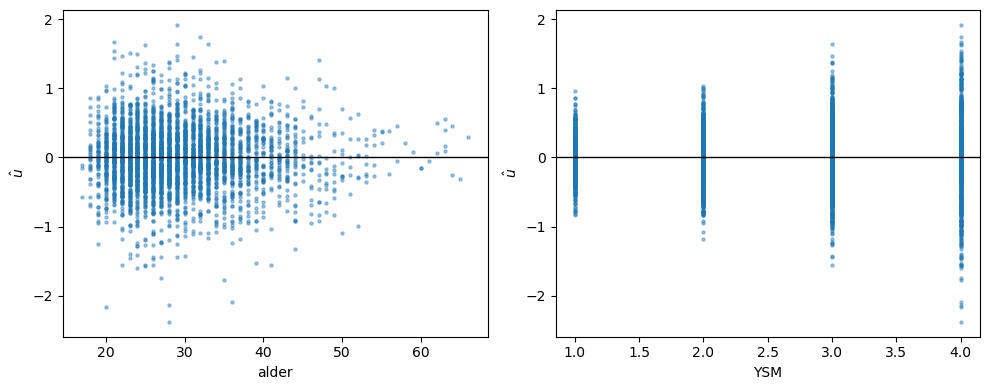

In [40]:
#3.c - Grafisk test

u_hat  = model_m.resid
y_hat  = model_m.fittedvalues
X_m    = X[mand]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for ax, (x, navn) in zip(axs, [(X_m['alder'], 'alder'),
                               (X_m['YSM'], 'YSM')]):
    ax.scatter(x, u_hat, s=5, alpha=0.4)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel(navn)
    ax.set_ylabel(r'$\hat{u}$')

plt.tight_layout()
plt.show()

In [41]:
#3.c. Breusch-Pagan test

X_m = X[mand]
y_m = y[mand]

# 1. Residualer fra model (3) for mænd
u_hat  = model_m.resid
u_hat2 = u_hat ** 2

# 2. Regression af û² på alle forklarende variable
bp_model = sm.OLS(u_hat2, X_m).fit()

# 3. F-test fra R²
k = 6
n_m = int(model_m.nobs) #antal observationer i model_m
R2  = bp_model.rsquared #R2 fra bp_model

F_bp = (R2 / k) / ((1 - R2) / (n_m - k - 1))
p_bp = stats.f.sf(F_bp, k, n_m - k - 1)

print(f'R2 = {R2:.4f}')
print(f'F = {F_bp:.4f}, p = {p_bp:.2e}, frihedsgrader = ({k}, {n_m - k - 1})')

#test for forskellige grupper
tests = {
    'alder (alder, alder2)':          'alder = 0, alder2 = 0',
    'YSM (YSM, YSM2)':                'YSM = 0, YSM2 = 0',
    'ankomstår (kohorte15, kohorte16)': 'kohorte15 = 0, kohorte16 = 0',
}

for navn, hyp in tests.items():
    r = bp_model.f_test(hyp)
    print(f'{navn}')
    print(f'   H0: {hyp}')
    print(f'   F = {float(r.fvalue):.4f}, p = {float(r.pvalue):.2e}, '
          f'frihedsgrader = ({int(r.df_num)}, {int(r.df_denom)})')
    print()


R2 = 0.1363
F = 100.0099, p = 3.47e-117, frihedsgrader = (6, 3803)
alder (alder, alder2)
   H0: alder = 0, alder2 = 0
   F = 2.1835, p = 1.13e-01, frihedsgrader = (2, 3803)

YSM (YSM, YSM2)
   H0: YSM = 0, YSM2 = 0
   F = 118.8189, p = 8.82e-51, frihedsgrader = (2, 3803)

ankomstår (kohorte15, kohorte16)
   H0: kohorte15 = 0, kohorte16 = 0
   F = 0.6251, p = 5.35e-01, frihedsgrader = (2, 3803)



In [42]:
#5.a.

def simulate(n):

	##Parameterværdier
	beta0 = 2
	beta1 = 3
	beta2 = -1
	beta3 = -1

	# Step 2. Simuler data
	x1 = np.random.normal(loc=1, scale=2, size=n)   # x ~ N(1,4), dvs. std = 2
	x2 = np.random.normal(loc=1, scale=2, size=n)
	x3 = np.random.normal(loc=1, scale=2, size=n)
	eps = np.random.normal(loc=0, scale=0.5*x1**2)  # Var = 1/4 * x1^4, dvs. std = 0.5*x1^2
	y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + eps

	## Step 3: Estimer modellen med OLS
	X = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
	X = sm.add_constant(X)
	results = sm.OLS(y, X).fit()

	beta1_hat = results.params['x1']    # Estimat af beta1
	se        = results.bse['x1']       # Almindelig standardfejl
	se_robust = results.HC1_se['x1']    # Robust standardfejl

	## Step 4: Test H0: beta1 = 3 (afvis hvis |t| > 1.96)
	rej        = abs((beta1_hat - 3) / se) > 1.96
	rej_robust = abs((beta1_hat - 3) / se_robust) > 1.96

	return beta1_hat, se, se_robust, rej, rej_robust


def monte_carlo(n, reps=1000):
	np.random.seed(0)
	out = []

	for rep in range(reps):
		out.append(simulate(n))

	results = pd.DataFrame(out, columns=['beta1', 'se', 'se_robust', 'rej', 'rej_robust'])

	return results


res = monte_carlo(n=1000, reps=1000)
print(res.mean())
print(res['beta1'].std())


beta1         3.001703
se            0.067190
se_robust     0.136889
rej           0.341000
rej_robust    0.036000
dtype: float64
0.1361515295070886


In [43]:
#5.b

def simulate(n):

	##Parameterværdier
	beta0 = 2
	beta1 = 3
	beta2 = -1
	beta3 = -1

	# Step 2. Simuler data
	x1 = np.random.normal(loc=1, scale=2, size=n)   # x ~ N(1,4), dvs. std = 2
	x2 = np.random.normal(loc=1, scale=2, size=n)
	x3 = np.random.normal(loc=1, scale=2, size=n)
	eps = np.random.normal(loc=0, scale=0.5*x1**2)  # Var = 1/4 * x1^4, dvs. std = 0.5*x1^2
	y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + eps

	## Step 3: Estimer modellen med OLS
	X = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
	X = sm.add_constant(X)
	results = sm.OLS(y, X).fit()

	beta1_hat = results.params['x1']    # Estimat af beta1
	se        = results.bse['x1']       # Almindelig standardfejl
	se_robust = results.HC1_se['x1']    # Robust standardfejl

	## Step 4: Test H0: beta1 = 3 (afvis hvis |t| > 1.96)
	rej        = abs((beta1_hat - 3) / se) > 1.96
	rej_robust = abs((beta1_hat - 3) / se_robust) > 1.96

	return beta1_hat, se, se_robust, rej, rej_robust


def monte_carlo(n, reps=1000):
	np.random.seed(0)
	out = []

	for rep in range(reps):
		out.append(simulate(n))

	results = pd.DataFrame(out, columns=['beta1', 'se', 'se_robust', 'rej', 'rej_robust'])

	return results


res = monte_carlo(n=50, reps=1000)
print(res.mean())
print(res['beta1'].std())

beta1         3.026653
se            0.282740
se_robust     0.488704
rej           0.331000
rej_robust    0.074000
dtype: float64
0.5814043635794531


In [44]:
#5.c WLS for n = 50

def simulate(n):

	##Parameterværdier
	beta0 = 2
	beta1 = 3
	beta2 = -1
	beta3 = -1

	#Simuler data
	x1 = np.random.normal(loc=1, scale=2, size=n)   # x ~ N(1,4), dvs. std = 2
	x2 = np.random.normal(loc=1, scale=2, size=n)
	x3 = np.random.normal(loc=1, scale=2, size=n)
	eps = np.random.normal(loc=0, scale=0.5*x1**2)  # Var = 1/4 * x1^4, dvs. std = 0.5*x1^2
	y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + eps

	## Estimerer modellen med WLS
	X = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
	X = sm.add_constant(X)
	results = sm.WLS(y, X, weights=4/x1**4).fit()

	beta1_hat = results.params['x1']    # Estimat af beta1
	se        = results.bse['x1']       # Standardfejl

	## H0: beta1 = 3
	rej = abs((beta1_hat - 3) / se) > 1.96

	return beta1_hat, se, rej


def monte_carlo(n, reps=1000):
	np.random.seed(0)
	out = []

	for rep in range(reps):
		out.append(simulate(n))

	results = pd.DataFrame(out, columns=['beta1', 'se', 'rej'])

	return results


res = monte_carlo(n=50, reps=1000)
print(res.mean())
print(res['beta1'].std())

beta1    3.000037
se       0.048533
rej      0.059000
dtype: float64
0.053157496748567436


In [45]:
#5.c WLS for n = 1000

def simulate(n):

	##Parameterværdier
	beta0 = 2
	beta1 = 3
	beta2 = -1
	beta3 = -1

	#Simuler data
	x1 = np.random.normal(loc=1, scale=2, size=n)   # x ~ N(1,4), dvs. std = 2
	x2 = np.random.normal(loc=1, scale=2, size=n)
	x3 = np.random.normal(loc=1, scale=2, size=n)
	eps = np.random.normal(loc=0, scale=0.5*x1**2)  # Var = 1/4 * x1^4, dvs. std = 0.5*x1^2
	y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + eps

	## Estimerer modellen med WLS
	X = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
	X = sm.add_constant(X)
	results = sm.WLS(y, X, weights=4/x1**4).fit()

	beta1_hat = results.params['x1']    # Estimat af beta1
	se        = results.bse['x1']       # Standardfejl

	## H0: beta1 = 3
	rej = abs((beta1_hat - 3) / se) > 1.96

	return beta1_hat, se, rej


def monte_carlo(n, reps=1000):
	np.random.seed(0)
	out = []

	for rep in range(reps):
		out.append(simulate(n))

	results = pd.DataFrame(out, columns=['beta1', 'se', 'rej'])

	return results


res = monte_carlo(n=1000, reps=1000)
print(res.mean())
print(res['beta1'].std())

beta1    2.999981
se       0.002389
rej      0.054000
dtype: float64
0.002538735657739635
